# Paged Attention in LLMs
When running LLMs at scale, the real limitation is GPU memory rather than compute, mainly because each request requires a KV cache to store token-level data. In traditional setups, a large fixed memory block is reserved per request based on the maximum sequence length, which leads to significant unused space and limits concurrency. Paged Attention improves this by breaking the KV cache into smaller, flexible chunks that are allocated only when needed, similar to how virtual memory works. It also allows multiple requests with the same starting prompt to share memory and only duplicate it when their outputs start to differ. This approach greatly improves memory efficiency, allowing significantly higher throughput with very little overhead.

In this article, we simulate the naive KV cache allocator, build a working Paged Attention implementation with a block table and Copy-on-Write prefix sharing, and measure the utilisation gap across batch sizes of 10 to 200 concurrent requests.

## Importing the dependencies

In [7]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

random.seed(42)
np.random.seed(42)

## Setting up the Constants
Before simulating anything, we need to know how much GPU memory a single token actually costs. This depends entirely on the model's architecture. We use a GPT-style configuration — 32 layers, 32 attention heads, 128 dimensions per head, stored in fp16. The factor of 2 at the front accounts for both the Key and Value projections (there is no Q cache — queries are recomputed at each step). Multiplying these out gives us 524,288 bytes, or 512 KB, per token. This is the fundamental unit everything else is built on — pre-allocation sizes, page counts, and wasted memory all scale directly from this number.

In [8]:
NUM_LAYERS  = 32
NUM_HEADS   = 32
HEAD_DIM    = 128
BYTES_FP16  = 2
PAGE_SIZE   = 16    # tokens per page (vLLM default)
MAX_SEQ_LEN = 2048

KV_BYTES_PER_TOKEN = 2 * NUM_LAYERS * NUM_HEADS * HEAD_DIM * BYTES_FP16
KV_MB_PER_TOKEN    = KV_BYTES_PER_TOKEN / 1024 / 1024

## Naive KV Cache
The naive approach is simple: when a request arrives, a contiguous block of GPU memory is allocated sized to the maximum sequence length — 2048 tokens in this case. This happens because the response length is unknown upfront, so the worst case is reserved.

AVG_RESPONSE is set to 500, which is a realistic average for a production chatbot. Multiplying by KV_MB_PER_TOKEN gives what is actually written versus what was locked. The gap is the waste.

The numbers make the problem concrete. Each request pre-allocates 1024 MB but uses only 250 MB — 24.4% utilisation. The remaining 774 MB sits reserved for the entire duration of the request, unavailable to any other request. Across 100 concurrent users, that is 75 GB of GPU memory doing nothing. This is not an edge case — it is the default behavior of every system that does not implement paged allocation, and it is exactly why naive serving systems hit an OOM wall long before the GPU is computationally saturated.

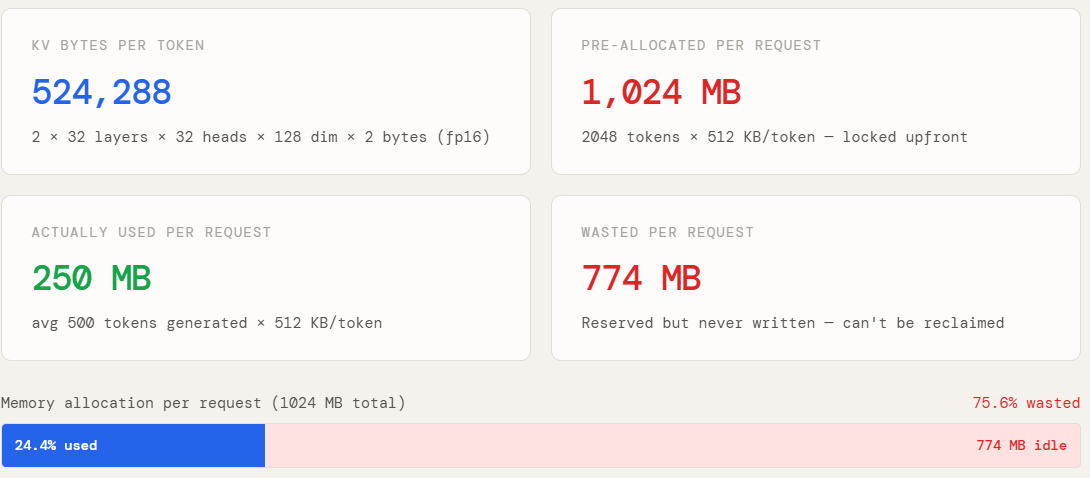

In [9]:
print("=" * 60)
print("SECTION 1 — Naive KV Cache: The Waste Problem")
print("=" * 60)

AVG_RESPONSE = 500   # realistic average tokens generated

pre_allocated_mb = MAX_SEQ_LEN  * KV_MB_PER_TOKEN
actually_used_mb = AVG_RESPONSE * KV_MB_PER_TOKEN

print(f"\nKV cache per token    : {KV_BYTES_PER_TOKEN:,} bytes")
print(f"Pre-allocated/request : {pre_allocated_mb:.2f} MB  ({MAX_SEQ_LEN} tokens)")
print(f"Actually used/request : {actually_used_mb:.2f} MB  ({AVG_RESPONSE} tokens)")
print(f"Utilisation           : {actually_used_mb / pre_allocated_mb * 100:.1f}%")
print(f"Wasted per request    : {pre_allocated_mb - actually_used_mb:.2f} MB")

NUM_USERS = 100
wasted_gb = (pre_allocated_mb - actually_used_mb) * NUM_USERS / 1024
print(f"\nAcross {NUM_USERS} concurrent users → {wasted_gb:.2f} GB wasted")
print("\n→ Naive systems utilise only 20–38% of allocated KV cache memory")
print("  (source: original Paged Attention / vLLM paper)")

SECTION 1 — Naive KV Cache: The Waste Problem

KV cache per token    : 524,288 bytes
Pre-allocated/request : 1024.00 MB  (2048 tokens)
Actually used/request : 250.00 MB  (500 tokens)
Utilisation           : 24.4%
Wasted per request    : 774.00 MB

Across 100 concurrent users → 75.59 GB wasted

→ Naive systems utilise only 20–38% of allocated KV cache memory
  (source: original Paged Attention / vLLM paper)


## Paged Attention: Pages + Block Table
Two classes are introduced here to simulate how Paged Attention actually works at the memory management level.

PagePool represents the physical GPU memory pool — a flat array of equal-size pages, each holding 16 tokens. It maintains a free list and a ref count per page. When a page's ref count drops to zero, it is immediately returned to the free list and becomes available to any new request. This is the key difference from naive allocation — there are no reserved holes, no fragmentation, and no memory tied to a finished request.

PagedRequest represents a single inference request. It holds a block_table — a list that maps logical page indices to physical page ids in the pool. Every time generate_token() is called and the token count crosses a page boundary, a new physical page is claimed from the pool. No memory is touched before it is needed.

Five requests are run with token counts of 320, 48, 160, 96, and 272. The output shows pages allocated proportionally to actual usage — req-1 with 48 tokens gets 3 pages, req-0 with 320 tokens gets 20. When req-1 is freed, its 3 pages go straight back to the pool and are immediately reusable. The pool utilisation at 10.9% looks low only because 512 pages were provisioned for 5 small requests — in a fully loaded production pool it would sit near the 98% range seen in Section 4. The "0 tokens wasted" in the last-page column is a seed artifact — all five token counts happen to be exact multiples of 16. In practice, the average last-page waste is PAGE_SIZE / 2 = 8 tokens per request.

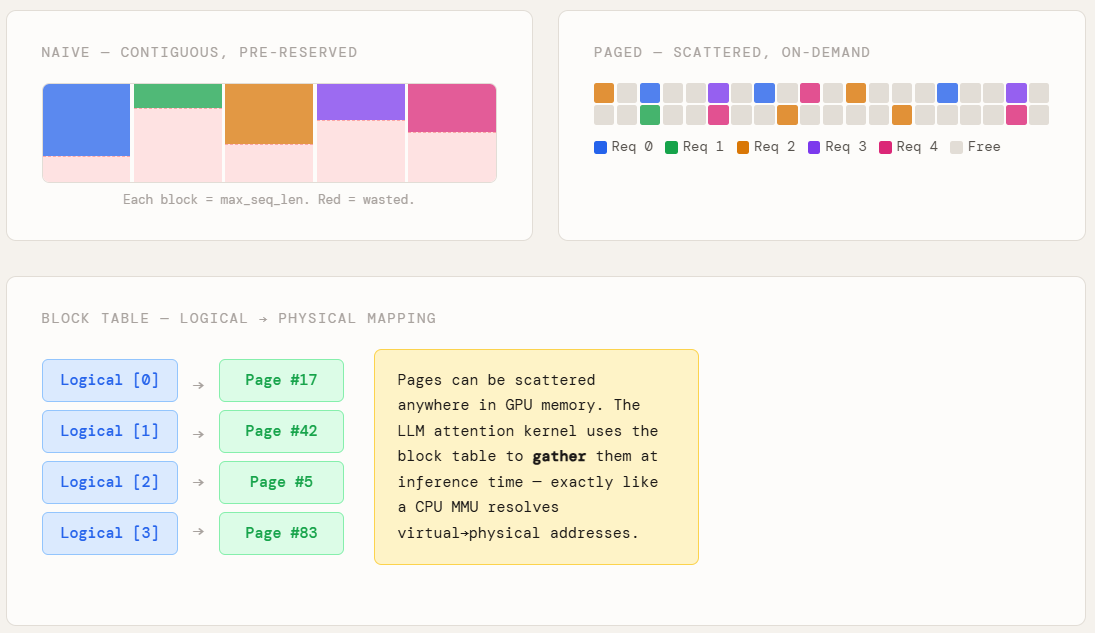

In [10]:
print("\n" + "=" * 60)
print("SECTION 2 — Paged Attention: Pages + Block Table")
print("=" * 60)

"""
Instead of one large contiguous block per request:
  - KV cache is split into fixed-size pages (PAGE_SIZE tokens each)
  - Pages are allocated on demand, can live anywhere in GPU memory
  - Each request keeps a block_table: logical index → physical page id
"""

class PagePool:
    def __init__(self, total_pages):
        self.free      = list(range(total_pages))
        self.total     = total_pages
        self.ref_count = defaultdict(int)

    def allocate(self):
        if not self.free:
            raise MemoryError("OOM — no free pages")
        pid = self.free.pop(0)
        self.ref_count[pid] = 1
        return pid

    def release(self, pid):
        self.ref_count[pid] -= 1
        if self.ref_count[pid] <= 0:
            self.free.append(pid)
            del self.ref_count[pid]

    def share(self, pid):
        """Increment ref count — another request is sharing this page."""
        self.ref_count[pid] += 1

    def cow_copy(self, pid):
        """CoW: allocate a new page, decrement ref on the old one."""
        new_pid = self.allocate()
        self.release(pid)
        return new_pid

    @property
    def utilisation(self):
        return (self.total - len(self.free)) / self.total * 100


class PagedRequest:
    def __init__(self, req_id, pool: PagePool):
        self.id          = req_id
        self.pool        = pool
        self.block_table = []   # logical index → physical page id
        self.tokens      = 0

    def generate_token(self):
        if self.tokens % PAGE_SIZE == 0:   # page boundary → allocate new page
            self.block_table.append(self.pool.allocate())
        self.tokens += 1

    def free(self):
        for pid in self.block_table:
            self.pool.release(pid)
        self.block_table.clear()


pool = PagePool(total_pages=512)
requests = [PagedRequest(f"req-{i}", pool) for i in range(5)]
token_counts = [320, 48, 160, 96, 272]

for req, n in zip(requests, token_counts):
    for _ in range(n):
        req.generate_token()

print("\nRequest state after generation:")
print(f"  {'ID':<10} {'Tokens':>8} {'Pages':>7} {'Last-page waste':>16}")
for req in requests:
    waste = req.tokens % PAGE_SIZE
    waste = PAGE_SIZE - waste if waste else 0
    print(f"  {req.id:<10} {req.tokens:>8} {len(req.block_table):>7} {waste:>16} tokens")

print(f"\nPool utilisation : {pool.utilisation:.1f}%")
requests[1].free()
print(f"After freeing req-1 → utilisation: {pool.utilisation:.1f}%  (pages immediately reusable)")


SECTION 2 — Paged Attention: Pages + Block Table

Request state after generation:
  ID           Tokens   Pages  Last-page waste
  req-0           320      20                0 tokens
  req-1            48       3                0 tokens
  req-2           160      10                0 tokens
  req-3            96       6                0 tokens
  req-4           272      17                0 tokens

Pool utilisation : 10.9%
After freeing req-1 → utilisation: 10.4%  (pages immediately reusable)


## Copy-on-Write: Shared System Prompts
In production, nearly every request to a deployed LLM carries the same system prompt — the instructions that define the model's behavior. Under naive allocation, each of those requests stores its own full copy of the system prompt's KV cache. With 10 concurrent requests and a 200-token system prompt, that is 10 identical copies of the same data occupying separate memory regions.

The same PagePool from Section 2 is reused here, extended with two methods: share() increments a page's ref count without allocating anything new, and cow_copy() allocates a fresh page and decrements the ref count on the original. A new pool is instantiated and the system prompt is encoded into 13 pages — math.ceil(200 / 16). Each of the 10 user requests then calls share() on all 13 pages, pointing their block tables at the same physical memory. No new pages are allocated. The ref count on each shared page simply rises to 11.

The savings are immediate: naive allocation would require 130 pages across 10 requests. With CoW, only 13 physical pages exist. That is 936 MB saved from a single shared prefix.

When req-3 generates its first unique token, cow_copy() is called on its last shared page — page 12. A new page 13 is allocated as req-3's private copy, and the ref count on page 12 drops by one. The other 9 requests continue pointing at page 12, completely unaffected. This is the CoW contract: shared until divergence, private only when necessary.

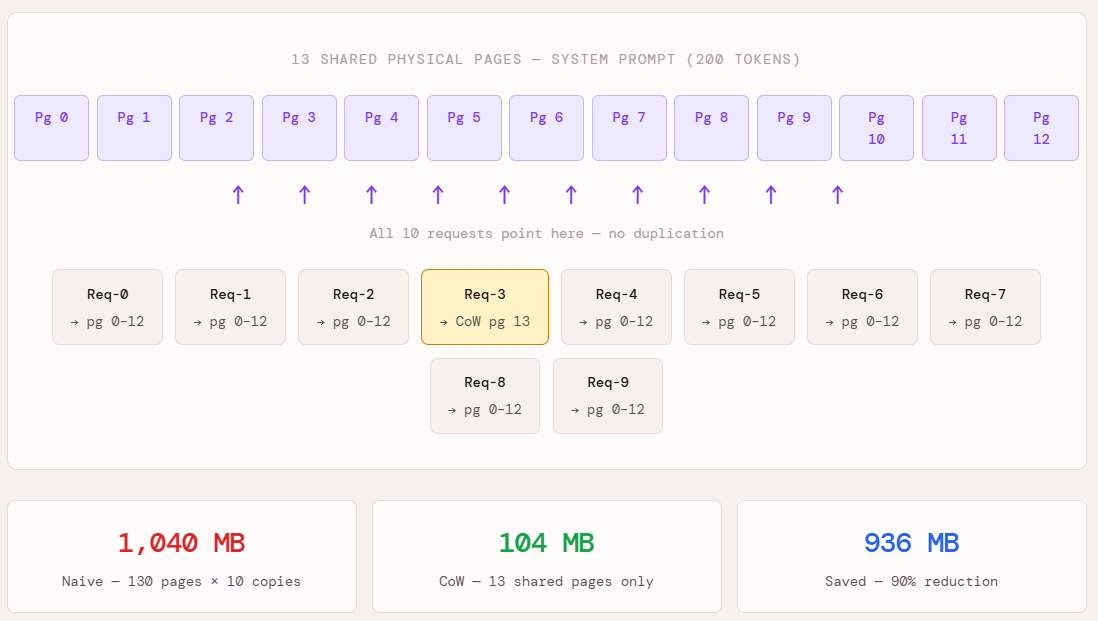

In [11]:
print("\n" + "=" * 60)
print("SECTION 3 — Copy-on-Write: Shared System Prompts")
print("=" * 60)

"""
If N requests share a system prompt, naive allocation stores N copies.
With CoW, all requests point to the SAME physical pages.
A private copy is made only when a request writes a diverging token.
"""

cow_pool    = PagePool(total_pages=512)
SYSTEM_TOKENS = 200
system_pages  = math.ceil(SYSTEM_TOKENS / PAGE_SIZE)
shared_pids   = [cow_pool.allocate() for _ in range(system_pages)]
print(f"\nSystem prompt → {system_pages} shared pages: {shared_pids}")

N = 10
user_tables = []
for i in range(N):
    table = list(shared_pids)
    for pid in shared_pids:
        cow_pool.share(pid)     # ref count up — no physical copy
    user_tables.append(table)

saved_mb = (system_pages * N - system_pages) * PAGE_SIZE * KV_MB_PER_TOKEN
print(f"\nStoring system prompt for {N} requests:")
print(f"  Naive : {system_pages * N} pages  ({system_pages * N * PAGE_SIZE * KV_MB_PER_TOKEN:.1f} MB)")
print(f"  CoW   : {system_pages} pages   ({system_pages * PAGE_SIZE * KV_MB_PER_TOKEN:.1f} MB)")
print(f"  Saved : {saved_mb:.1f} MB")

old_pid                 = user_tables[3][-1]
new_pid                 = cow_pool.cow_copy(old_pid)
user_tables[3][-1]      = new_pid
print(f"\nReq-3 diverges → CoW: old page {old_pid} → new page {new_pid}")
print(f"All other {N-1} requests still share page {old_pid} unaffected")


SECTION 3 — Copy-on-Write: Shared System Prompts

System prompt → 13 shared pages: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Storing system prompt for 10 requests:
  Naive : 130 pages  (1040.0 MB)
  CoW   : 13 pages   (104.0 MB)
  Saved : 936.0 MB

Req-3 diverges → CoW: old page 12 → new page 13
All other 9 requests still share page 12 unaffected


## Utilisation: Naive vs Paged
Two functions are defined to measure utilisation under each approach across different batch sizes.

naive_utilisation draws token counts from a normal distribution with avg=500 and std=200, clipped to [200, 2048]. This reflects a realistic production distribution — most responses fall between 200 and 800 tokens, with occasional long ones. For each request, the full 2048-slot block is pre-allocated regardless. Utilisation is then actual_tokens_sum / (2048 × n) — the ratio of what was written to what was reserved.

paged_utilisation takes the same actual token counts but computes how many pages each request would need — ceil(tokens / 16). The only waste is the unfilled tail of each request's last page, which averages 8 tokens. Utilisation is actual_tokens_sum / (pages_allocated × 16).

The results are run across batch sizes of 10, 25, 50, 100, and 200. Naive utilisation hovers around 24% across all batch sizes — with some variance at smaller batches due to sampling noise — which is exactly avg / max_seq = 500 / 2048. It does not improve with scale because the waste is structural, not statistical.

Paged utilisation sits flat at ~98.5% regardless of batch size, because the waste per request is bounded by a single partial page and does not scale with max_seq_len at all. The gap between the two numbers — roughly 74 percentage points — is directly what enables vLLM to fit 2–4× more concurrent requests into the same GPU memory.

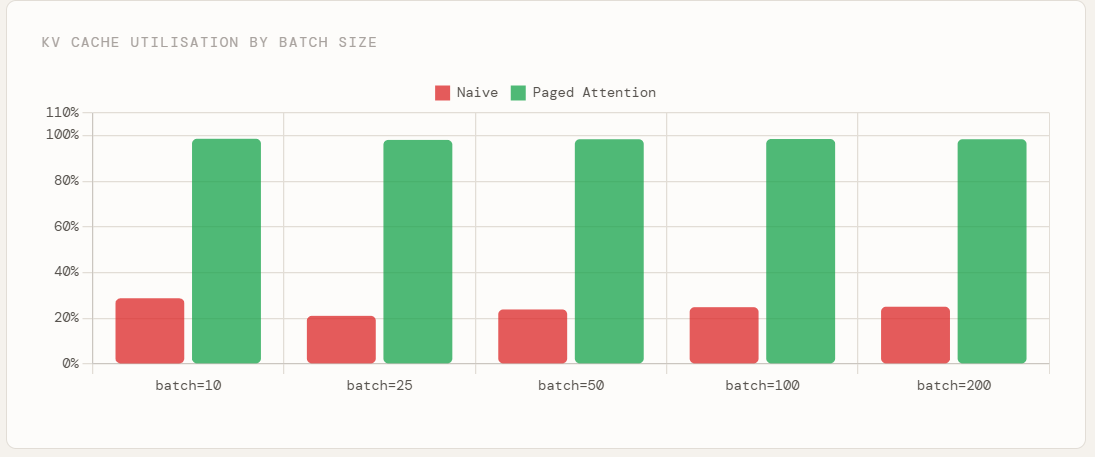

In [12]:
print("\n" + "=" * 60)
print("SECTION 4 -- Utilisation: Naive vs Paged")
print("=" * 60)

def naive_utilisation(n, max_seq=2048, avg=500, std=200):
    actual = np.clip(np.random.normal(avg, std, n).astype(int), 200, max_seq)
    return actual.sum() / (max_seq * n) * 100, actual

def paged_utilisation(actual_tokens, page_size=PAGE_SIZE):
    pages = np.ceil(actual_tokens / page_size).astype(int)
    return actual_tokens.sum() / (pages * page_size).sum() * 100

batch_sizes = [10, 25, 50, 100, 200]
naive_u, paged_u = [], []

print(f"\n  {'Batch':>6}   {'Naive':>8}   {'Paged':>8}")
for bs in batch_sizes:
    nu, actual = naive_utilisation(bs)
    pu = paged_utilisation(actual)
    naive_u.append(nu)
    paged_u.append(pu)
    print(f"  {bs:>6}   {nu:>7.1f}%   {pu:>7.1f}%")


SECTION 4 — Utilisation: Naive vs Paged

   Batch      Naive      Paged
      10      28.8%      98.7%
      25      21.1%      98.2%
      50      23.9%      98.5%
     100      24.9%      98.6%
     200      25.1%      98.5%
